# 🚗 Car Price Prediction using Machine Learning

### Oasis Infobyte Data Science Internship – Task 3

**Submitted by:** Mitanshi Sad

## Objective

The objective of this project is to predict the selling price of used cars using machine learning techniques based on features such as present price, manufacturing year, fuel type, seller type, transmission, kilometers driven, and ownership history.

## Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the no tebook
%matplotlib inline

# Load the Dataset

In [2]:
#Load the car price dataset
df=pd.read_csv("car data.csv")

# Data Exploration

In [3]:
#display the first five rows of the dataset
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Checking the number of rows and columns
df.shape

(301, 9)

In [5]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


## Observation

The dataset contains **301 records** and **9 columns**. All columns have **301 non-null values**, indicating that there are **no missing values** in the dataset. The dataset includes both numerical and categorical features, making it suitable for machine learning after preprocessing.

In [6]:
# Display all column names
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [7]:
# Generate summary statistics
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
# check for missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Observation

The dataset does not contain any missing values. All columns have complete information, so no data cleaning is required for missing values before building the machine learning model.

## Data cleaning

In [9]:
# Check for duplicate rows 
df.duplicated().sum()

np.int64(2)

In [10]:
# remove duplicate rows
df=df.drop_duplicates()

In [11]:
# check duplicate again
df.duplicated().sum()

np.int64(0)

In [12]:
# check the dataset size after removing duplicates
df.shape

(299, 9)

## Observation

The dataset initially contained **2 duplicate records**. These duplicate rows were removed to improve data quality and prevent the machine learning model from learning the same information multiple times. After removing duplicates, the dataset contains **299 records**.

## Checking Categorical Values

The categorical columns are checked to ensure that there are no inconsistent values such as different spellings or letter cases (for example, "Petrol" and "petrol"). This helps maintain data consistency before model training.

In [13]:
# Display unique values in Fuel_Type

df["Fuel_Type"].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

In [14]:
# Display unique values in Seller_Type

df["Seller_Type"].unique()

<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str

In [15]:
# Display unique values in Transmission

df["Transmission"].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

## Observation

The categorical columns (`Fuel_Type`, `Seller_Type`, and `Transmission`) contain consistent values with no spelling or letter-case inconsistencies. Therefore, no additional cleaning is required for these features.

## Feature Engineering: Car Age

A new feature named **Car_Age** is created by subtracting the manufacturing year from the current year (2026). Car age is expected to have a significant impact on the selling price of a used car.

In [16]:
# Create a new feature: Car_Age

df["Car_Age"] = 2026 - df["Year"]

In [17]:
# Display Year and Car_Age columns

df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [18]:
# Extract the brand name from Car_Name

df["Brand"] = df["Car_Name"].str.split().str[0]

In [19]:
# Display Car_Name and Brand columns

df[["Car_Name", "Brand"]].head(10)

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


## Brand Feature Analysis

The brand name is extracted from the `Car_Name` column by taking the first word of each car name. This creates a new feature named **Brand**, which may help improve the prediction of the selling price.

In [20]:
df.drop("Brand", axis=1, inplace=True)

## Note

The provided dataset contains car model names (such as *swift*, *ciaz*, *ritz*, and *wagon r*) instead of full manufacturer names (such as Maruti Suzuki, Honda, or Hyundai). Therefore, extracting the first word from `Car_Name` does not produce the actual car brand. Hence, no separate **Brand** feature was used for model training.

# Exploratory Data Analysis (EDA)

In this section, we explore the dataset using visualizations to understand the distribution of car selling prices and how different features affect the selling price.

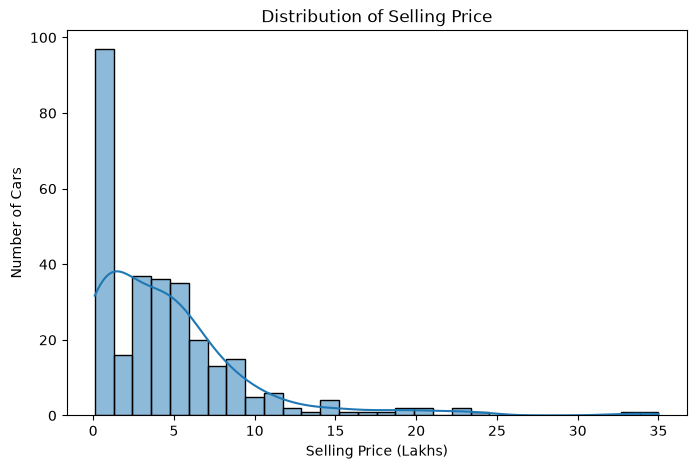

In [21]:
# Distribution of Selling Price

plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

## Observation

The histogram shows that most cars have a selling price between **₹0 and ₹8 lakhs**. As the selling price increases, the number of cars decreases significantly. The distribution is **right-skewed**, indicating that the dataset contains many affordable cars and only a few high-priced cars.

## Selling Price vs Fuel Type

A box plot is used to compare the distribution of selling prices for different fuel types. It helps identify differences in median prices, variability, and potential outliers.

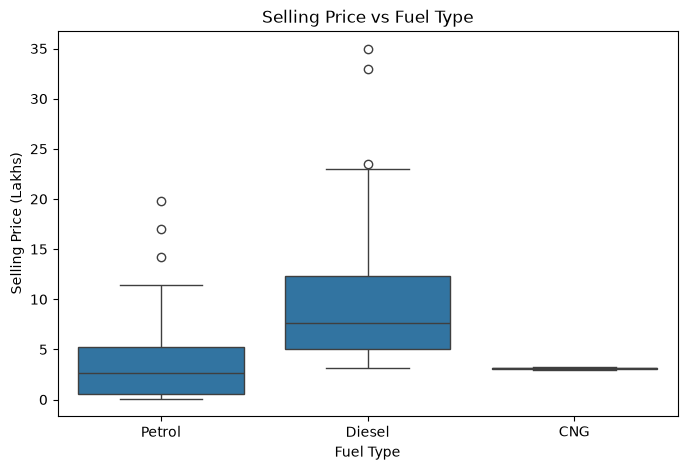

In [22]:
# Selling Price vs Fuel Type

plt.figure(figsize=(8,5))

sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

## Observation

The box plot shows that **Diesel cars generally have higher selling prices** compared to Petrol and CNG cars. Petrol cars are available across a wider range of prices, while CNG cars have very little variation due to the small number of records. The plot also shows several outliers, indicating a few high-priced Petrol and Diesel cars.

## Selling Price vs Car Age

A scatter plot is used to study the relationship between the age of a car and its selling price. This helps determine whether older cars generally sell for lower prices.

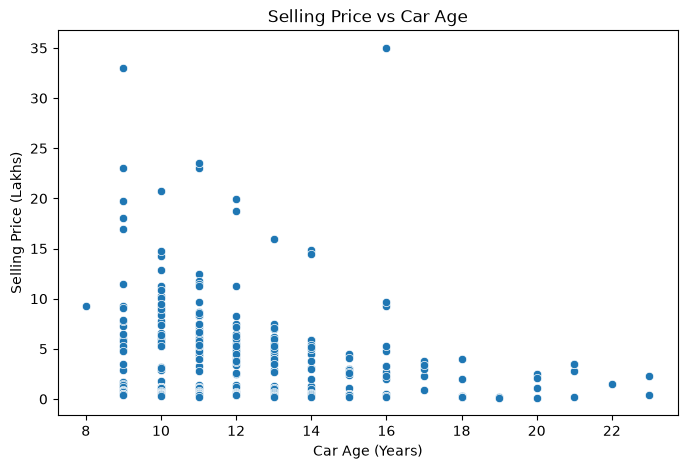

In [23]:
# Selling Price vs Car Age

plt.figure(figsize=(8,5))

sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

## Observation

The scatter plot indicates a **negative relationship** between car age and selling price. In general, newer cars tend to have higher selling prices, while older cars are sold at lower prices. A few outliers are present, showing that some older cars still have relatively high selling prices.

## Feature Correlation Heatmap

A correlation heatmap is used to understand the relationship between numerical features in the dataset. It helps identify which features are positively or negatively correlated with the selling price.

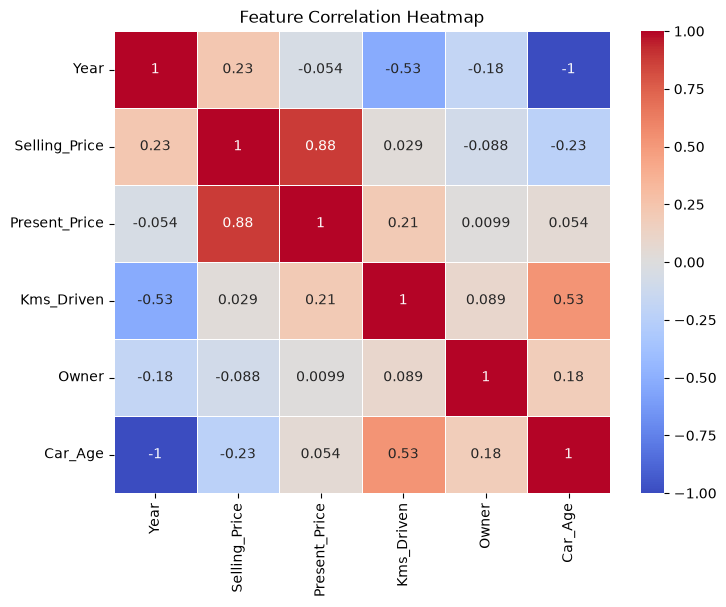

In [24]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Plot correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Observation

The heatmap shows that **Present_Price** has the strongest positive correlation (**0.88**) with **Selling_Price**, indicating that cars with higher showroom prices generally have higher selling prices. **Car_Age** has a negative correlation with **Selling_Price**, suggesting that older cars tend to sell for lower prices. The **Year** and **Car_Age** columns have a perfect negative correlation because car age is calculated directly from the manufacturing year.

# Data Preprocessing

In [25]:
# Convert categorical variables into numerical variables

df_encoded = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

In [26]:
# Display the first five rows of the encoded dataset

df_encoded.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,12,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,13,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,9,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,15,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,12,True,False,False,True


## Encoding Categorical Variables

The categorical features (`Fuel_Type`, `Seller_Type`, and `Transmission`) are converted into numerical format using **One-Hot Encoding**. The `drop_first=True` parameter is used to remove one category from each feature to avoid redundant information and multicollinearity.

## Preparing Features and Target

The input features (**X**) are created by removing the `Car_Name` and `Selling_Price` columns from the dataset. The `Selling_Price` column is stored separately as the target variable (**y**) because it is the value that the machine learning model will learn to predict.

In [27]:
# Create input features (X) and target variable (y)

X = df_encoded.drop(["Car_Name", "Selling_Price"], axis=1)

y = df_encoded["Selling_Price"]

In [28]:
# Display the first five rows of X

X.head()

,Year,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,12,False,True,False,True
1,2013,9.54,43000,0,13,True,False,False,True
2,2017,9.85,6900,0,9,False,True,False,True
3,2011,4.15,5200,0,15,False,True,False,True
4,2014,6.87,42450,0,12,True,False,False,True


In [29]:
# Display the first five values of y

y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

## Train-Test Split

The dataset is divided into training and testing sets using an **80:20 ratio**. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data. The `random_state=42` parameter ensures that the data is split in the same way every time the notebook is executed.

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (239, 9)
Testing data: (60, 9)
Training target: (239,)
Testing target: (60,)


## Observation

The dataset has been successfully divided into training and testing sets. The training set contains **239 samples**, while the testing set contains **60 samples**. Each sample has **9 input features**. The training data will be used to train the machine learning model, and the testing data will be used to evaluate its performance on unseen data.

# Model Building



## Linear Regression Model

A **Linear Regression** model is created and trained using the training dataset. The model learns the relationship between the input features and the selling price. After training, the model predicts the selling prices for the testing dataset using the learned relationships.

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.17, 0.44,-0. ,..., 0.69,-1.3 ,-1.57]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Year','Present_Price','Kms_Driven',...,'Fuel_Type_Petrol', 'Seller_Type_Individual','Transmission_Manual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-328.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [36]:
y_pred = model.predict(X_test)

## Model Evaluation

The performance of the Linear Regression model is evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**. Lower values of MAE and RMSE indicate better prediction accuracy, while a higher R² Score indicates that the model explains a larger proportion of the variation in the selling price.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.4728924140033344
RMSE: 2.524035054595348
R² Score: 0.7528154215831805


## Observation

The Linear Regression model achieved a **Mean Absolute Error (MAE)** of **1.47**, indicating that the predicted selling prices differ from the actual prices by about **1.47 lakhs** on average. The **Root Mean Squared Error (RMSE)** is **2.52**, suggesting the presence of some larger prediction errors. The **R² Score** of **0.75** indicates that the model explains approximately **75%** of the variation in the selling prices, showing good overall predictive performance.

## Random Forest Regressor

A **Random Forest Regressor** is trained using the training dataset. It consists of multiple decision trees that work together to predict the selling price of a car. The final prediction is obtained by averaging the predictions from all the decision trees, making the model more robust and accurate.

In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [40]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [41]:
rf_pred = rf_model.predict(X_test)

## Random Forest Model Evaluation

The Random Forest Regressor is evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**. These metrics help compare its performance with the Linear Regression model. Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates better model performance.

In [42]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE : 1.5282866666666672
Random Forest RMSE: 3.7062210873071253
Random Forest R² Score: 0.4670416717307717


## Observation

The Random Forest Regressor achieved a **Mean Absolute Error (MAE)** of **1.53**, a **Root Mean Squared Error (RMSE)** of **3.71**, and an **R² Score** of **0.47**. Compared with the Linear Regression model, the Random Forest model performed worse on this dataset because it had higher prediction errors and a lower R² Score. Therefore, **Linear Regression is the better-performing model for this dataset**.

## Feature Importance

The feature importance values are extracted from the trained **Random Forest Regressor**. These values indicate how much each feature contributes to predicting the selling price. Features with higher importance values have a greater influence on the model's predictions.

In [43]:
importance = rf_model.feature_importances_

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [45]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
1,Present_Price,0.901491
0,Year,0.043161
4,Car_Age,0.036361
2,Kms_Driven,0.010267
8,Transmission_Manual,0.004761
7,Seller_Type_Individual,0.002238
5,Fuel_Type_Diesel,0.001007
6,Fuel_Type_Petrol,0.000711
3,Owner,0.000003


## Observation

The feature importance analysis shows that **Present_Price** is the most influential feature, with an importance score of **0.90**, indicating that it has the greatest impact on predicting the selling price of a car. The **Year** and **Car_Age** features also contribute to the prediction but to a much smaller extent. Features such as **Owner**, **Fuel Type**, **Seller Type**, and **Transmission** have relatively low importance, suggesting that they have less influence on the model's predictions.

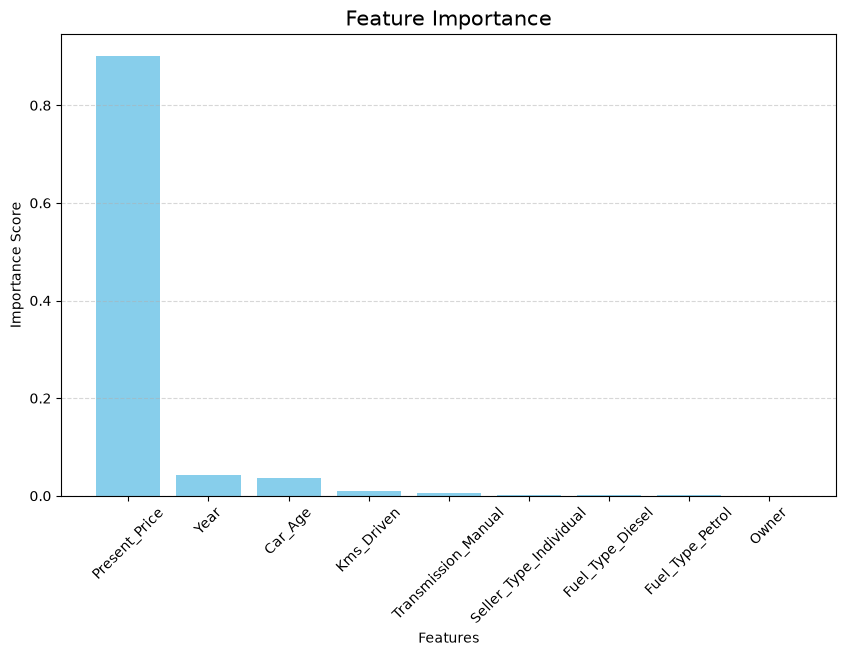

In [46]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="skyblue"
)

plt.title("Feature Importance", fontsize=15)

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Observation

The feature importance graph shows that **Present_Price** is the most influential feature in predicting the selling price of a car. **Year** and **Car_Age** also contribute to the prediction, but their importance is much lower. Features such as **Kms_Driven**, **Transmission**, **Seller_Type**, **Fuel_Type**, and **Owner** have comparatively less impact on the model's predictions.

## Model Comparison

Both Linear Regression and Random Forest Regressor were trained and evaluated on the dataset. Based on the evaluation metrics, **Linear Regression performed better** than Random Forest for this dataset. It achieved a lower MAE and RMSE along with a higher R² Score, indicating more accurate predictions.

# Conclusion

In this project, a car price prediction model was developed using machine learning techniques. The dataset was cleaned by removing duplicate records, feature engineering was performed by creating the **Car_Age** feature, and exploratory data analysis was conducted to understand the relationships between different variables.

The categorical features were encoded using One-Hot Encoding, and two regression models, **Linear Regression** and **Random Forest Regressor**, were trained and evaluated. Based on the evaluation metrics, **Linear Regression achieved better performance** with a lower prediction error and a higher R² Score than Random Forest on this dataset.

Feature importance analysis showed that **Present_Price** is the most significant factor influencing the selling price of a car, followed by **Year** and **Car_Age**. Overall, the project demonstrates how machine learning can be used to estimate used car prices effectively.